# 03 - Feature engineering
Turns the order-level base table (notebook 01) into the analytical base table (ABT) used for modelling. Each feature has a stated reason; anything that is only known **after** delivery is kept out of the delivery-time model (see notebook 04).

Output: `data/cleaned/analytical_base_table.csv`.

In [1]:
import json, pathlib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", rc={"axes.titleweight": "bold"})
RED, DARK = "#E23744", "#2D2D2D"
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
CLEAN, IMG, REP = ROOT / "data" / "cleaned", ROOT / "images", ROOT / "reports"
IMG.mkdir(exist_ok=True)

d = pd.read_csv(CLEAN / "order_base.csv", parse_dates=["OrderDate", "RegistrationDate", "OrderTS"])
restaurants = pd.read_csv(CLEAN / "restaurants.csv"); partners = pd.read_csv(CLEAN / "delivery_partners.csv")
d["hour"], d["dow"] = d.OrderTS.dt.hour, d.OrderDate.dt.dayofweek
d["month"] = d.OrderDate.dt.to_period("M").astype(str)
print(d.shape)

(20475, 55)


## 1. Engineered features

In [2]:
# ---- The 11 PRD features + a few supporting ones. Each line says WHY the feature should matter. ----
COMPLETED = ["Delivered", "Delivered Late"]

d["PeakHour"] = (d.hour.between(12, 13) | d.hour.between(19, 21)).astype(int)          # lunch/dinner rush
d["WeekendOrder"] = (d.dow >= 5).astype(int)
d["RainImpact"] = pd.cut(d.Rainfall, [-1, 0.5, 10, 50, np.inf], labels=[0, 1, 2, 3]).astype(int)   # none / light / moderate / heavy (mm)
d["CustomerTenure"] = (d.OrderDate - d.RegistrationDate).dt.days                       # days since sign-up at order time
d["IsDelivered"] = d.OrderStatus.isin(COMPLETED)
d["IsCancelled"] = (d.OrderStatus == "Cancelled").astype(int); d["IsLate"] = (d.OrderStatus == "Delivered Late").astype(int)
d["HasCoupon"] = d.CouponCode.notna().astype(int); d["DiscountPct"] = np.where(d.FoodCost > 0, d.Discount / d.FoodCost, 0)

# customer-level aggregates - for ANALYSIS ONLY (they use all orders; the churn notebook recomputes them with a cutoff to avoid leakage)
d = d.sort_values(["CustomerID", "OrderTS"]); g = d.groupby("CustomerID")
d["AverageBasketValue"] = g.FinalAmount.transform("mean")
d["CustomerLifetimeValue"] = g.FinalAmount.transform("sum")
span = (g.OrderTS.transform("max") - g.OrderTS.transform("min")).dt.days.clip(lower=30)
d["OrderFrequency"] = g.OrderID.transform("count") / (span / 30.0)                      # orders per 30 days

# restaurant popularity inside its city
rp = d.groupby(["RCity", "RestaurantID"]).agg(RestOrders=("OrderID", "count"), RestRevenue=("FinalAmount", "sum")).reset_index()
rp["RestaurantPopularityRank"] = rp.groupby("RCity").RestOrders.rank(ascending=False, method="min")
rp["RestaurantRevenueRank"] = rp.groupby("RCity").RestRevenue.rank(ascending=False, method="min")
d = d.merge(rp, on=["RCity", "RestaurantID"], how="left")

# partner efficiency = partner's average delivery time / city average (< 1 means faster than the city norm)
city_avg = partners.groupby("City").AverageDeliveryTime.mean()
d["DeliveryEfficiency"] = d.AverageDeliveryTime / d.PCity.map(city_avg)

d["RestaurantAvgFeedback"] = d.groupby("RestaurantID").AvgRating.transform("mean")
print("engineered features added:", ["PeakHour", "WeekendOrder", "RainImpact", "CustomerTenure", "AverageBasketValue", "CustomerLifetimeValue", "OrderFrequency", "RestaurantPopularityRank", "DeliveryEfficiency"])

engineered features added: ['PeakHour', 'WeekendOrder', 'RainImpact', 'CustomerTenure', 'AverageBasketValue', 'CustomerLifetimeValue', 'OrderFrequency', 'RestaurantPopularityRank', 'DeliveryEfficiency']


## 2. Distance proxy

In [3]:
# ---- Distance: be honest about what the data allows ----
# Customers carry NO coordinates, so true restaurant->customer distance cannot be computed. We build a PROXY instead:
# distance from the restaurant to the centroid of restaurants in its city (a measure of how peripheral the restaurant is).
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))
cen = restaurants.groupby("City")[["Latitude", "Longitude"]].mean()
d["DistanceProxyKm"] = haversine_km(d.Latitude, d.Longitude, d.RCity.map(cen.Latitude), d.RCity.map(cen.Longitude))
print("customer city == restaurant city for only", f"{(d.CCity == d.RCity).mean():.1%}", "of orders -> customer location is effectively unknown")
d = d.sort_values("OrderID").reset_index(drop=True); d.DistanceProxyKm.describe().round(2)

customer city == restaurant city for only 4.0% of orders -> customer location is effectively unknown


count    20475.00
mean       944.20
std        362.78
min          9.89
25%        677.75
50%        943.66
75%       1232.86
max       1860.73
Name: DistanceProxyKm, dtype: float64

## 3. Save and check completeness

In [4]:
d.to_csv(CLEAN / "analytical_base_table.csv", index=False)
print("saved analytical_base_table.csv", d.shape)
# data-quality check: the 11 PRD features must be complete
feats = ["PeakHour", "WeekendOrder", "RainImpact", "TrafficScore", "CustomerTenure", "AverageBasketValue", "RestaurantPopularityRank", "DeliveryEfficiency", "CustomerLifetimeValue", "OrderFrequency", "AvgRating", "DistanceProxyKm", "BasketSize"]
d[feats].isna().sum().rename("nulls").to_frame().T

saved analytical_base_table.csv (20475, 74)


,PeakHour,WeekendOrder,RainImpact,TrafficScore,CustomerTenure,AverageBasketValue,RestaurantPopularityRank,DeliveryEfficiency,CustomerLifetimeValue,OrderFrequency,AvgRating,DistanceProxyKm,BasketSize
nulls,0,0,0,0,0,0,0,0,0,0,6410,0,0


## 4. Feature relationships
Correlation is a screening tool: it only shows linear association and says nothing about cause.

strongest |correlation| with delivery time: 0.016


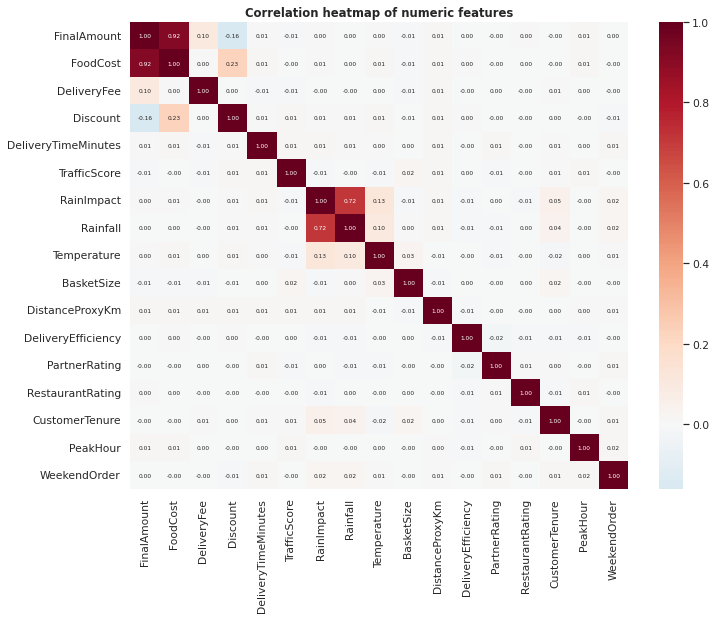

,DeliveryFee,RestaurantRating,DeliveryEfficiency,PeakHour,WeekendOrder,Temperature,Rainfall,CustomerTenure,FinalAmount,RainImpact,BasketSize,Discount,DistanceProxyKm,FoodCost,TrafficScore,PartnerRating
corr with DeliveryTimeMinutes,-0.007,-0.006,-0.001,-0.001,0.004,0.004,0.004,0.007,0.009,0.009,0.009,0.01,0.01,0.013,0.014,0.016


In [5]:
# ---- Which features relate to delivery time? (completed orders only) ----
dl = d[d.IsDelivered & d.DeliveryTimeMinutes.notna()]
num = ["FinalAmount", "FoodCost", "DeliveryFee", "Discount", "DeliveryTimeMinutes", "TrafficScore", "RainImpact", "Rainfall", "Temperature", "BasketSize", "DistanceProxyKm",
       "DeliveryEfficiency", "PartnerRating", "RestaurantRating", "CustomerTenure", "PeakHour", "WeekendOrder"]
def save(fig, name, kind): fig.tight_layout(); fig.savefig(IMG / f"eda_{kind}_{name}.png", dpi=120)
f, a = plt.subplots(figsize=(11, 9)); sns.heatmap(d[num].corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 6}, ax=a); a.set(title="Correlation heatmap of numeric features"); save(f, "01_corr_heatmap", "sns")
r = dl[num].corr()["DeliveryTimeMinutes"].drop("DeliveryTimeMinutes").sort_values()
print("strongest |correlation| with delivery time:", r.abs().max().round(3)); r.round(3).to_frame("corr with DeliveryTimeMinutes").T

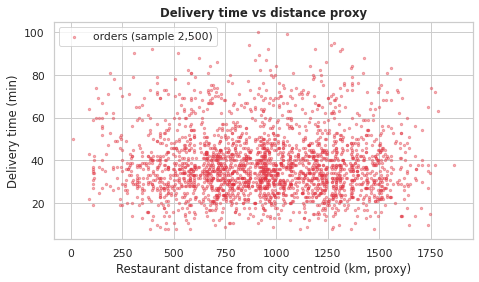

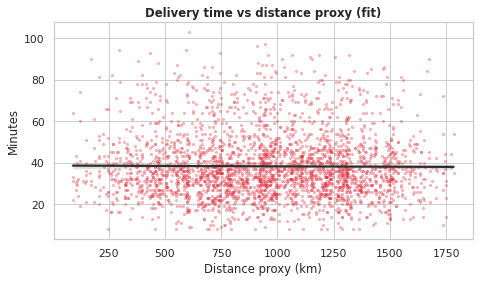

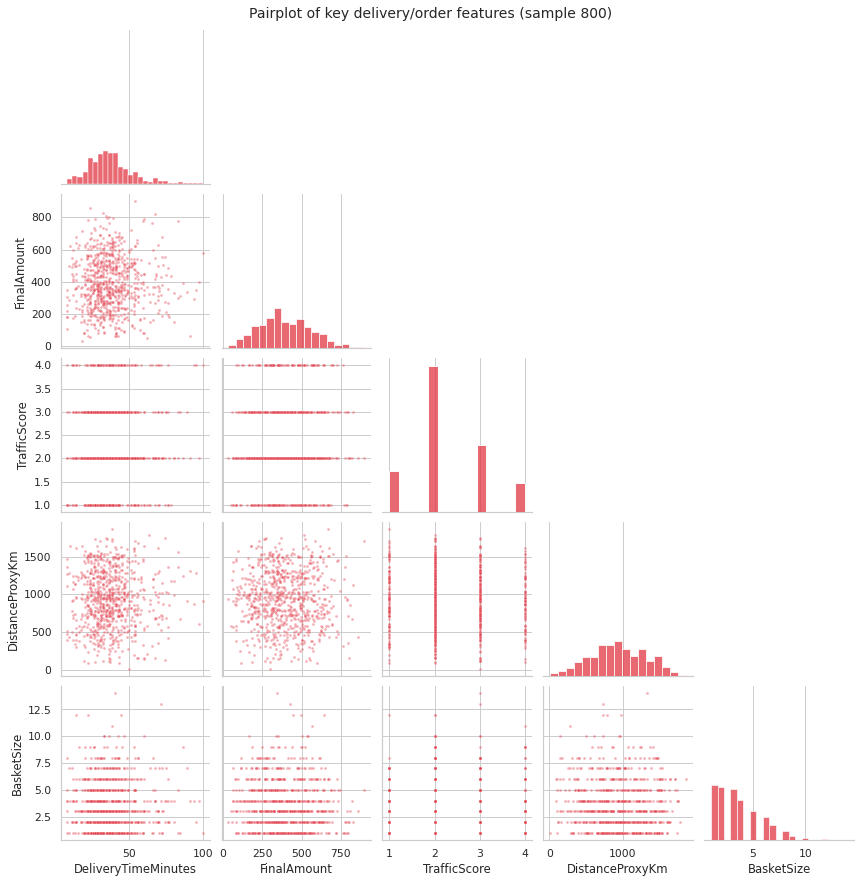

In [6]:
# ---- Feature vs target charts ----
sm = dl.sample(2500, random_state=1)
f, a = plt.subplots(figsize=(7, 4.2)); a.scatter(sm.DistanceProxyKm, sm.DeliveryTimeMinutes, s=6, alpha=.4, color=RED, label="orders (sample 2,500)"); a.set(title="Delivery time vs distance proxy", xlabel="Restaurant distance from city centroid (km, proxy)", ylabel="Delivery time (min)"); a.legend(); save(f, "05_scatter_time_vs_distance", "mpl")
sm2 = dl.sample(3000, random_state=2)
f, a = plt.subplots(figsize=(7, 4.2)); sns.regplot(data=sm2, x="DistanceProxyKm", y="DeliveryTimeMinutes", scatter_kws=dict(s=5, alpha=.3, color=RED), line_kws=dict(color=DARK), ax=a); a.set(title="Delivery time vs distance proxy (fit)", xlabel="Distance proxy (km)", ylabel="Minutes"); save(f, "08_reg_time_vs_distance", "sns")
pp = sns.pairplot(dl[["DeliveryTimeMinutes", "FinalAmount", "TrafficScore", "DistanceProxyKm", "BasketSize"]].dropna().sample(800, random_state=1), corner=True, plot_kws=dict(s=8, alpha=.4, color=RED), diag_kws=dict(color=RED))
pp.figure.suptitle("Pairplot of key delivery/order features (sample 800)", y=1.01); pp.figure.savefig(IMG / "eda_sns_02_pairplot.png", dpi=110)

In [7]:
# Set the chart counts in kpis.json from the PNGs actually written (idempotent - safe to re-run)
k = json.load(open(REP / "kpis.json")); k["mpl_charts"] = len(list(IMG.glob("eda_mpl_*.png"))); k["sns_charts"] = len(list(IMG.glob("eda_sns_*.png")))
json.dump(k, open(REP / "kpis.json", "w"), indent=2); (k["mpl_charts"], k["sns_charts"])

(20, 18)

## Reading the results
* No single feature has a strong linear relationship with delivery time - the maximum |correlation| is small. Notebook 04 tests whether a non-linear model can do better.
* `OrderFrequency`, `CustomerLifetimeValue` and `AverageBasketValue` use *all* of a customer's orders. They are valid for describing customers but **would leak the future** if used to predict churn, so notebook 05 recomputes them before a cutoff date.